In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [32]:
train = pd.read_csv("train (3).csv")
test = pd.read_csv("test (1).csv")
submission = pd.read_csv("gender_submission.csv")

print("train: ", train.shape)
print("test: ", test.shape)
print("submis: ", submission.shape)

display(train.head())
display(train.info())
display(train.describe(include="all"))

train:  (891, 12)
test:  (418, 11)
submis:  (418, 2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [33]:
display(train.isna().sum().sort_values(ascending=False).head(20))

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [34]:
display(train["Survived"].value_counts())
display(train["Survived"].value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [35]:
x = train.drop(columns=["Survived"])
y = train["Survived"].copy()
x_test = test.copy()

# Drop yang tidak dipakai: PassengerId (ID), Name/Ticket (terlalu unik),
# Cabin (77% missing). Harus assignment, kalau tidak hasilnya hilang.
DROP_COLS = ["PassengerId", "Name", "Ticket", "Cabin"]
x = x.drop(columns=DROP_COLS)
x_test = x_test.drop(columns=DROP_COLS)

print("fitur train:", x.columns.tolist())
print("fitur test :", x_test.columns.tolist())


fitur train: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
fitur test : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [36]:
fitur_numerik = x.select_dtypes(include=np.number).columns.tolist()
fitur_kategorikal = x.select_dtypes(exclude=np.number).columns.tolist()

In [37]:
x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [38]:
numerik_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

kategorikal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [39]:
transformers = []
if fitur_numerik:
    transformers.append(
        ("num", numerik_pipeline, fitur_numerik)
    )
    
if fitur_kategorikal:
    transformers.append(
        ("cat", kategorikal_pipeline, fitur_kategorikal)
    )
    
preprocessor = ColumnTransformer(
    transformers=transformers
)

In [40]:
model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

model_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

model_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", C=1.0, random_state=42))
])

akurasi:  0.8100558659217877
f1_score:  0.7932744565217391
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



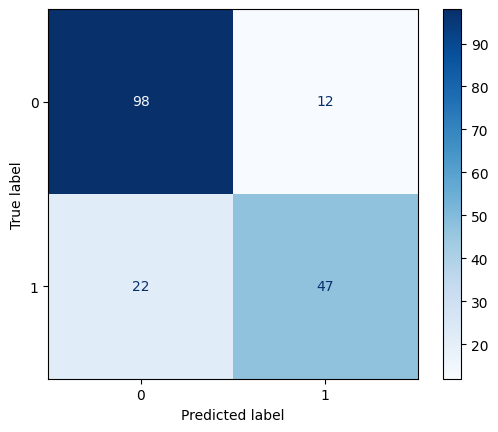

In [41]:
model_rf.fit(x_train, y_train)
valid_prediction = model_rf.predict(x_valid)

print("akurasi: ", accuracy_score(y_valid, valid_prediction))
print("f1_score: ", f1_score(y_valid, valid_prediction, average="macro"))
print(classification_report(y_valid, valid_prediction, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_valid, valid_prediction, cmap="Blues"
)
plt.show()

In [42]:
model_rf.fit(x, y)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
model_svm.fit(x, y)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
test_prediction = model_rf.predict(x_test)

In [45]:
submission1 = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_prediction.astype(int)
})

print(submission1.head(10))
print(submission1["Survived"].value_counts())

# Simpan untuk upload ke Kaggle (Submit -> Upload submission.csv)
submission1.to_csv("submission.csv", index=False)
print("tersimpan: submission.csv", submission1.shape)


   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0
Survived
0    266
1    152
Name: count, dtype: int64
tersimpan: submission.csv (418, 2)
